### 1. Импортируем библиотеки

Здесь подключаем:
- `datasets` для загрузки датасета BBC;
- `pandas`, `numpy` для работы с данными;
- инструменты для обработки текста;
- модель тематического моделирования (LDA или BERTopic).


In [1]:
import pandas as pd
import numpy as np

from datasets import load_dataset

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
import seaborn as sns


/mnt/d/Python/Projects/PythonProject/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Загружаем датасет BBC

Нас интересуют:
- текст новости;
- её класс (label).


In [4]:
dataset = load_dataset("SetFit/bbc-news")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (1225, 3)
Test shape: (1000, 3)


,text,label,label_text
0,wales want rugby league training wales could f...,2,sport
1,china aviation seeks rescue deal scandal-hit j...,1,business
2,rock band u2 break ticket record u2 have smash...,3,entertainment
3,markets signal brazilian recovery the brazilia...,1,business
4,tough rules for ringtone sellers firms that fl...,0,tech


Мы загрузили датасет `SetFit/bbc-news` с разделением на train и test.

- Обучающая выборка: 1225 документов, 3 столбца.
- Тестовая выборка: 1000 документов, 3 столбца.

В данных есть:
- `text` — текст новости;
- `label` — числовая метка класса;
- `label_text` — название класса (`business`, `entertainment`, `politics`, `sport`, `tech`).

Дальше для тематического моделирования будем работать с полем `text` отдельно по каждому значению `label_text`.

### 3. Разделяем новости по классам

Для тематического моделирования нам нужно отдельно анализировать
каждый класс (`business`, `entertainment`, `politics`, `sport`, `tech`).

На этом шаге:
- получаем список названий классов;
- собираем для каждого класса отдельный список текстов новостей.


In [5]:
label_names = sorted(train_df["label_text"].unique())
print("Классы BBC:", label_names)

texts_by_class = {
    label: train_df.loc[train_df["label_text"] == label, "text"].tolist()
    for label in label_names
}

docs_per_class = {label: len(texts) for label, texts in texts_by_class.items()}
docs_per_class


Классы BBC: ['business', 'entertainment', 'politics', 'sport', 'tech']


{'business': 286,
 'entertainment': 210,
 'politics': 242,
 'sport': 275,
 'tech': 212}

Мы выделили 5 классов новостей BBC:
`business`, `entertainment`, `politics`, `sport`, `tech`.

Для каждого класса собрали отдельный список текстов:
- business: 286 новостей;
- entertainment: 210 новостей;
- politics: 242 новости;
- sport: 275 новостей;
- tech: 212 новостей.

Дальше будем строить отдельную модель тематического моделирования (LDA)
для текстов каждого класса.


### 4. Функция для построения LDA по одному классу

Сделаем функцию, которая для заданного набора текстов:
- преобразует их в мешок слов (CountVectorizer);
- обучит модель LDA с заданным числом тем;
- вернёт обученную модель, векторизатор и матрицу признаков.

Эту функцию потом будем вызывать отдельно для каждого класса.


In [6]:
def build_lda_for_texts(texts, n_topics=5, max_features=5000, random_state=42):
    """
    texts: список строк (новостей одного класса)
    n_topics: количество тем для поиска
    """
    vectorizer = CountVectorizer(
        max_df=0.9,
        min_df=5,
        max_features=max_features,
        stop_words="english"
    )
    X = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=random_state,
        learning_method="batch"
    )
    lda.fit(X)

    return lda, vectorizer, X


### 5. Функция для вывода топ-слов по темам

Чтобы интерпретировать темы LDA, нам нужно увидеть,
какие слова чаще всего встречаются в каждой теме.

Сделаем вспомогательную функцию, которая:
- берёт обученную модель LDA и векторизатор;
- для каждой темы выводит список из нескольких самых важных слов.


In [7]:
def get_topics(lda, vectorizer, n_top_words=10):
    feature_names = np.array(vectorizer.get_feature_names_out())
    topics = []
    for topic_idx, topic in enumerate(lda.components_):
        top_features_idx = topic.argsort()[::-1][:n_top_words]
        top_features = feature_names[top_features_idx]
        topics.append((topic_idx, top_features))
    return topics


### 6. Прогон LDA для одного класса (пример: business)

Сначала протестируем наш пайплайн на одном классе — `business`:
- обучим модель LDA на новостях этого класса;
- получим список тем;
- посмотрим топ-слова по каждой теме.

Если всё будет выглядеть разумно, затем запустим тот же процесс для всех классов.


In [8]:
sample_label = "business"
sample_texts = texts_by_class[sample_label]

lda_business, vect_business, X_business = build_lda_for_texts(
    sample_texts,
    n_topics=5
)

business_topics = get_topics(lda_business, vect_business, n_top_words=10)

print(f"Темы для класса '{sample_label}':\n")
for idx, words in business_topics:
    print(f"Тема {idx}: {', '.join(words)}")


Темы для класса 'business':

Тема 0: year, government, economic, mr, budget, world, countries, china, economy, new
Тема 1: company, mr, shares, firm, firms, companies, new, market, financial, chief
Тема 2: oil, yukos, government, state, russian, firm, bank, company, gazprom, russia
Тема 3: year, growth, sales, economy, market, 2004, prices, rise, rates, bank
Тема 4: deutsche, lse, boerse, london, bid, stock, offer, market, exchange, takeover


### Темы для класса business

Модель LDA выделила следующие темы:

- **Тема 0:** `year, government, economic, budget, countries, china, economy, world`  
  Похожа на макроэкономику и роль правительства: бюджеты, экономическая ситуация, мировая экономика.

- **Тема 1:** `company, shares, firm, companies, market, financial, chief`  
  Тематика отдельных компаний: акции, отчётность, финансовые результаты, руководители.

- **Тема 2:** `oil, yukos, government, state, russian, bank, gazprom, russia`  
  Нефть, российские компании и государственное регулирование, энергетический сектор.

- **Тема 3:** `year, growth, sales, economy, market, prices, rise, rates, bank`  
  Экономический рост, продажи, динамика цен и процентных ставок, состояние рынка.

- **Тема 4:** `deutsche, lse, boerse, london, bid, stock, offer, exchange, takeover`  
  Биржи и сделки поглощения: Лондонская биржа, Deutsche Börse, предложения о выкупе, рынки акций.

**Вывод для business:**  
В бизнес-новостях BBC основное внимание уделяется макроэкономике и роли государства, результатам и акциям отдельных компаний, нефтегазовому сектору, динамике роста и цен, а также биржевым сделкам и поглощениям.


### 7. Обучаем LDA для всех классов

Теперь повторим тот же процесс для всех пяти классов:
`business`, `entertainment`, `politics`, `sport`, `tech`.

Для каждого класса:
- обучим свою модель LDA;
- сохраним результаты (темы, векторизатор, матрицу признаков);
- выведем топ-слова по темам.


In [9]:
lda_results = {}

for label in label_names:
    print(f"\n=== Класс: {label} ===")
    texts = texts_by_class[label]
    lda_model, vect, X = build_lda_for_texts(texts, n_topics=5)
    topics = get_topics(lda_model, vect, n_top_words=10)

    lda_results[label] = {
        "lda": lda_model,
        "vectorizer": vect,
        "X": X,
        "topics": topics,
    }

    for idx, words in topics:
        print(f"Тема {idx}: {', '.join(words)}")



=== Класс: business ===
Тема 0: year, government, economic, mr, budget, world, countries, china, economy, new
Тема 1: company, mr, shares, firm, firms, companies, new, market, financial, chief
Тема 2: oil, yukos, government, state, russian, firm, bank, company, gazprom, russia
Тема 3: year, growth, sales, economy, market, 2004, prices, rise, rates, bank
Тема 4: deutsche, lse, boerse, london, bid, stock, offer, market, exchange, takeover

=== Класс: entertainment ===
Тема 0: best, film, awards, award, won, year, director, oscar, actor, actress
Тема 1: said, year, tv, people, 000, million, big, new, festival, children
Тема 2: music, song, best, band, years, people, album, said, new, single
Тема 3: said, film, new, star, man, years, mr, singer, movie, court
Тема 4: number, film, films, box, office, album, year, chart, new, week

=== Класс: politics ===
Тема 0: mr, new, government, home, secretary, mps, blunkett, law, committee, house
Тема 1: people, children, labour, party, says, school,

### Темы по всем классам BBC

#### business

- **Тема 0:** `year, government, economic, budget, countries, china, economy`  
  Макроэкономика и политика: бюджеты, экономическая ситуация, роль правительства и Китая в мировой экономике.

- **Тема 1:** `company, shares, firm, companies, market, financial, chief`  
  Отдельные компании и рынки: акции, финансовые показатели, корпоративные новости и топ-менеджеры.

- **Тема 2:** `oil, yukos, government, state, russian, gazprom, russia`  
  Нефтегазовый сектор и российские госкомпании: ЮКОС, Газпром, влияние государства и банков.

- **Тема 3:** `year, growth, sales, economy, market, prices, rise, rates, bank`  
  Экономический рост и продажы: динамика цен, процентные ставки, состояние рынков.

- **Тема 4:** `deutsche, lse, boerse, london, bid, stock, exchange, takeover`  
  Биржи и сделки M&A: Лондонская биржа, Deutsche Börse, предложения о выкупе, фондовый рынок.

**Вывод для business:** новости фокусируются на макроэкономике, корпоративных результатах, энергетике и биржевых сделках.

---

#### entertainment

- **Тема 0:** `best, film, awards, oscar, actor, actress, director`  
  Награды и премии: Оскар, лучшие фильмы, режиссёры и актёры.

- **Тема 1:** `year, tv, people, big, festival, children`  
  Телевидение и массовые мероприятия: телешоу, фестивали, программы для детей.

- **Тема 2:** `music, song, band, album, single, years`  
  Музыка: группы, песни, альбомы, релизы и чарты.

- **Тема 3:** `film, star, man, singer, movie, court`  
  Звёзды кино и музыки: истории про знаменитостей, включая судебные разбирательства.

- **Тема 4:** `film, films, box, office, chart, week`  
  Прокат и рейтинги: сборы в кинотеатрах и позиции в чартах.

**Вывод для entertainment:** здесь доминируют темы кинонаград, музыкальной индустрии, ТВ‑контента и популярности фильмов и артистов.

---

#### politics

- **Тема 0:** `government, home secretary, mps, law, committee, house`  
  Внутренняя политика и законодательство: министры, парламент, законы, комитеты.

- **Тема 1:** `people, children, labour, party, school, police, calls`  
  Социальная политика: школы, дети, полиция, инициативы партий.

- **Тема 2:** `uk, rights, human, foreign, government, world, britain`  
  Внешняя политика и права человека: позиция Великобритании в мире.

- **Тема 3:** `government, plans, local, public, police, council`  
  Местное управление и госуслуги: планы правительства, местные советы, полиция.

- **Тема 4:** `labour, election, party, blair, howard, brown, leader`  
  Выборы и партийная борьба: Лейбористы, консерваторы, лидеры и кампании.

**Вывод для politics:** основное внимание на работе правительства, выборах, партийной конкуренции и социально‑политических вопросах внутри страны и на международной арене.

---

#### sport

- **Тема 0:** `world, olympic, drugs, athens, doping, athletics`  
  Лёгкая атлетика и Олимпийские игры, включая допинговые скандалы.

- **Тема 1:** `cup, players, club, team, rugby, world`  
  Командные виды спорта: кубки, клубы, игроки (футбол, регби).

- **Тема 2:** `final, win, set, open, title, match`  
  Турниры и финалы: победы, титулы, ключевые матчи.

- **Тема 3:** `liverpool, united, chelsea, game, goal, manager`  
  Топ‑клубы английского футбола и их выступления.

- **Тема 4:** `england, ireland, wales, nations, game, france, rugby`  
  Сборные и международные турниры (например, Турнир шести наций по регби).

**Вывод для sport:** доминируют темы международных турниров, футбольных клубов и сборных, крупных финалов и допинговых историй в лёгкой атлетике.

---

#### tech

- **Тема 0:** `apple, mac, mini, digital, music, tv, computer, ipod`  
  Продукты Apple и цифровые медиа‑устройства.

- **Тема 1:** `radio, gadgets, yahoo, mobile, search, sony`  
  Гаджеты и интернет‑сервисы: мобильные устройства, поисковые системы, бренды.

- **Тема 2:** `mobile, phone, video, tv, broadband, games, technology`  
  Мобильные телефоны, видео и широкополосный интернет.

- **Тема 3:** `users, net, site, technology, data, online, information`  
  Интернет‑пользователи, сайты, онлайн‑сервисы и данные.

- **Тема 4:** `software, computer, virus, security, mail`  
  Программное обеспечение и безопасность: вирусы, защита компьютеров и email.

**Вывод для tech:** раздел технологий BBC в основном освещает устройства (Apple, мобильные), интернет‑платформы, онлайн‑опыт пользователей и вопросы кибербезопасности.


### 8. Визуализация распределения тем внутри класса

Чтобы понять, какие темы доминируют в каждом классе,
посмотрим распределение документов по темам.

Сделаем функцию, которая:
- берёт обученную LDA‑модель и матрицу документов;
- для каждого документа выбирает наиболее вероятную тему;
- строит столбчатую диаграмму количества документов по темам.


In [10]:
def plot_topic_distribution(label, lda_result):
    lda = lda_result["lda"]
    X = lda_result["X"]

    # распределение тем по документам
    doc_topic_dist = lda.transform(X)           # shape: (n_docs, n_topics)
    dominant_topics = doc_topic_dist.argmax(axis=1)
    topic_counts = pd.Series(dominant_topics).value_counts().sort_index()

    plt.figure(figsize=(6, 4))
    sns.barplot(x=topic_counts.index, y=topic_counts.values, color="steelblue")
    plt.title(f"Распределение документов по темам для класса '{label}'")
    plt.xlabel("Номер темы")
    plt.ylabel("Количество документов")
    plt.tight_layout()
    plt.show()


### 9. Строим распределение тем для всех классов

Теперь построим одну диаграмму на каждый класс,
чтобы увидеть, как часто встречается каждая тема внутри:

- `business`
- `entertainment`
- `politics`
- `sport`
- `tech`


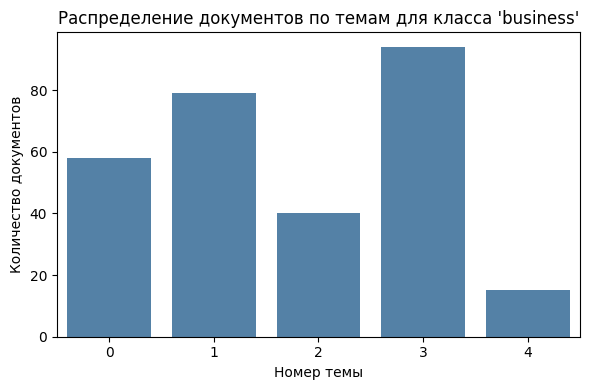

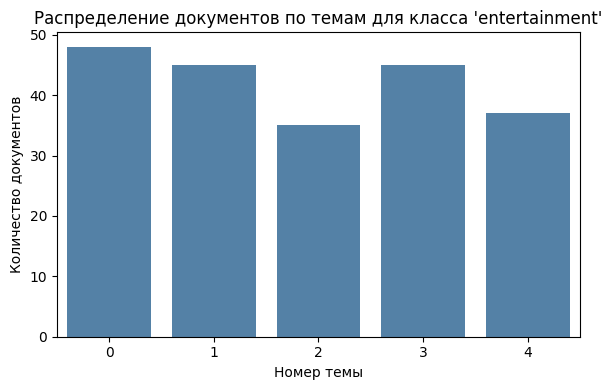

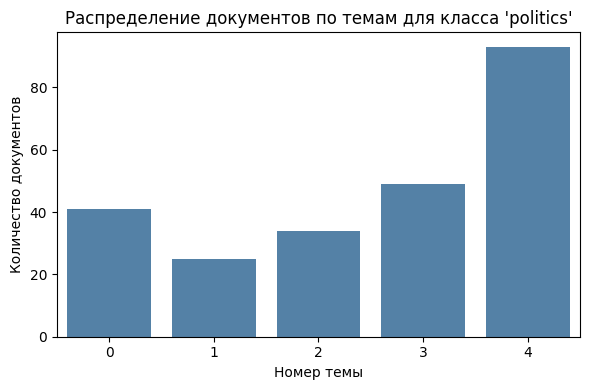

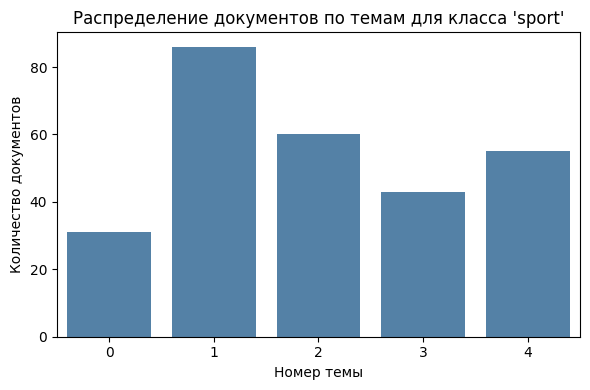

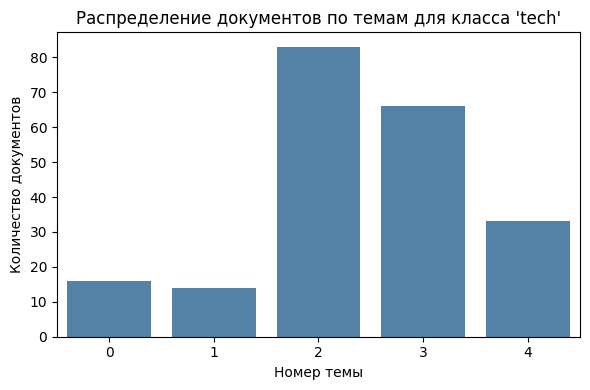

In [11]:
for label in label_names:
    plot_topic_distribution(label, lda_results[label])


### Распределение тем внутри классов

По барчартам видно, какие темы преобладают в каждом разделе:

- Для `business` основная нагрузка приходится на тему 3 (рост экономики, продажи, цены, процентные ставки).
- В `entertainment` темы распределены довольно равномерно, с лёгким перевесом тем 0 и 3 (награды и фильмы/звёзды).
- В `politics` доминирует тема 4, связанная с выборами, партиями и политическими лидерами.
- В `sport` наиболее частая тема 1 — новости о клубах, игроках и кубковых турнирах.
- В `tech` больше всего документов в теме 2, где речь идёт о мобильных телефонах, видео‑сервисах и широкополосном интернете.

Это подтверждает, что каждая LDA‑модель улавливает устойчивые подтемы внутри своего раздела BBC.


## 10. Итоговый вывод по заданию 2

В этом задании мы для каждого класса новостей BBC
(`business`, `entertainment`, `politics`, `sport`, `tech`)
построили отдельную LDA‑модель и рассмотрели:
- набор тем через топ‑слова;
- распределение документов по темам.

### business

Темы в разделе business отражают несколько устойчивых сюжетов:
- макроэкономика и роль государства (бюджет, экономический рост, страны, мировая экономика);
- корпоративные новости: компании, акции, финансовые результаты и руководители;
- нефтегазовый сектор и российские государственные компании (ЮКОС, Газпром);
- динамика продаж, цен и процентных ставок;
- биржевые сделки и поглощения вокруг крупных бирж (LSE, Deutsche Börse).

На барчарте доминирует тема с ростом, продажами и ценами —
это показывает, что в бизнес‑новостях BBC много материалов
про общую динамику экономики и рынков.

### entertainment

В entertainment выделяются темы:
- кинонаграды и премии (Оскар, лучшие фильмы, режиссёры, актёры);
- телевидение и массовые мероприятия (шоу, фестивали, программы);
- музыкальная индустрия (группы, альбомы, чарты);
- истории о звёздах кино и музыки, включая скандалы и суды;
- кассовые сборы и рейтинги фильмов.

Распределение тем довольно ровное, что говорит
о хорошем тематическом разнообразии: BBC освещает
и кино, и музыку, и ТВ, и популярность контента.

### politics

Для politics темы группируются вокруг:
- работы правительства, министров и парламента;
- социальной политики (школы, дети, полиция);
- внешней политики и прав человека;
- местного управления и общественных услуг;
- выборов и партийной борьбы (Лейбористы, консерваторы, лидеры).

Доминирование темы, связанной с выборами и партийной конкуренцией,
показывает, что значительная часть политических материалов BBC
сосредоточена на электоральной повестке и распределении власти.

### sport

В sport модель выделяет:
- лёгкую атлетику и Олимпийские игры, включая допинг‑кейсы;
- клубные турниры и кубки в командных видах спорта;
- финалы и борьбу за титулы;
- выступления топ‑клубов английского футбола;
- игры сборных и международные турниры (например, по регби).

По распределению тем видно, что сильнее всего представлены
новости о клубах и кубковых соревнованиях — именно они дают
основной объём спортивной повестки.

### tech

В tech преобладают темы:
- продукты Apple и другие цифровые устройства;
- гаджеты и интернет‑сервисы (поисковые системы, бренды);
- мобильные телефоны, видео и широкополосный интернет;
- онлайн‑платформы и данные пользователей;
- программное обеспечение и компьютерная безопасность (вирусы, защита).

Доминирующая тема связана с мобильными устройствами и онлайн‑сервисами,
что показывает фокус BBC на потребительских технологиях и
ежедневном цифровом опыте пользователей.

### Общий вывод

Тематическое моделирование показало, что внутри каждого класса BBC
существует несколько устойчивых подтем, которые интуитивно согласуются
с содержанием соответствующих разделов:

- business — экономика, компании, энергетика и биржи;
- entertainment — кино, музыка, ТВ и звёзды;
- politics — правительство, выборы, внутренняя и внешняя политика;
- sport — крупные турниры, клубы и сборные;
- tech — устройства, интернет‑платформы и кибербезопасность.

Таким образом, LDA‑модели позволяют не только увидеть,
как распределяются документы по темам внутри класса,
но и сформировать содержательное представление о том,
о чём в среднем говорит каждая категория новостей BBC.
